In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input

In [ ]:
# Veri yolu ve parametreleri
train_data_dir = '/content/drive/MyDrive/TomatoDisease/Dataset/train'
test_data_dir = '/content/drive/MyDrive/TomatoDisease/Dataset/test'
img_width, img_height = 224, 224
batch_size = 32
num_classes = 10

In [ ]:
# Veri ön işleme ve artırma
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 18365 images belonging to 10 classes.
Found 4605 images belonging to 10 classes.


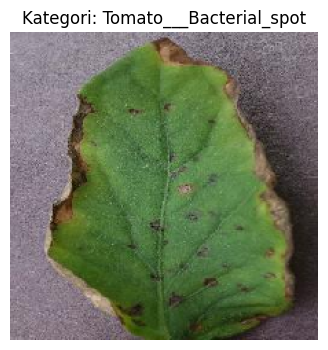

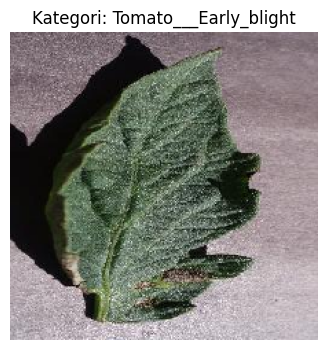

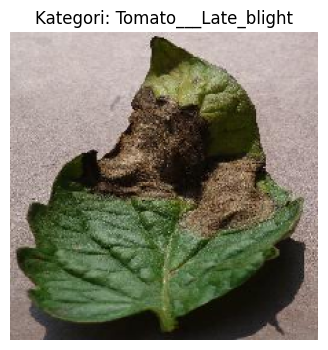

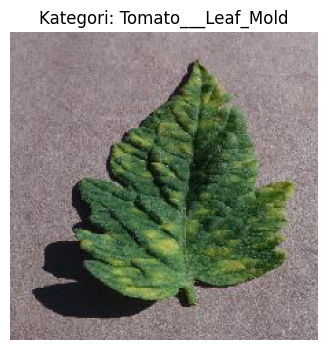

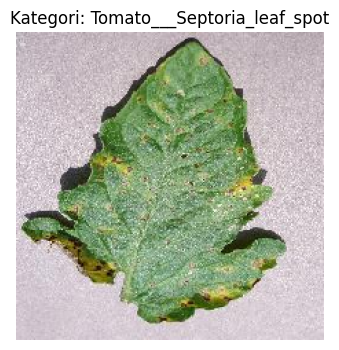

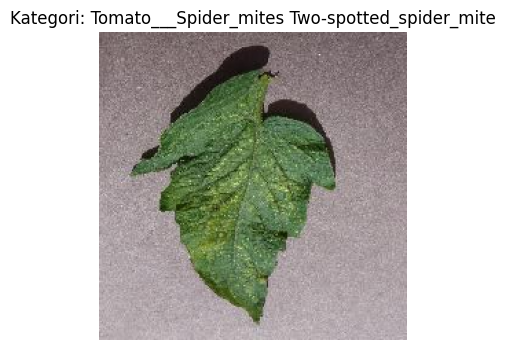

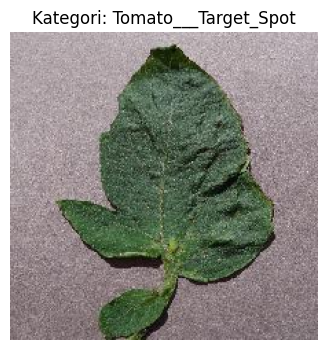

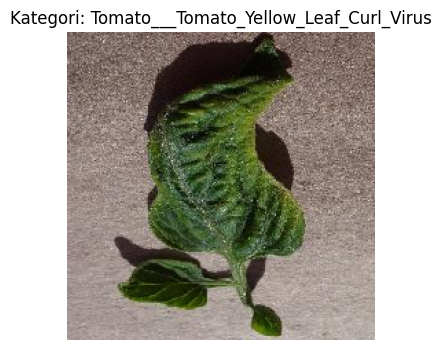

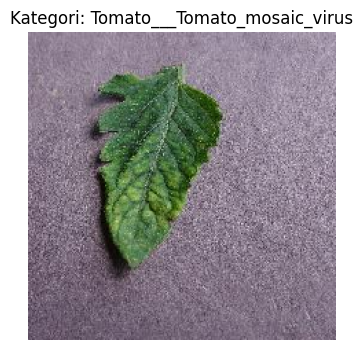

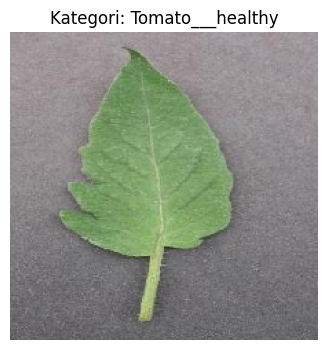

In [ ]:
# Her kategoriden bir eğitim seti örneği seçme ve görselleştirme
for class_name in train_generator.class_indices.keys():
    class_dir = os.path.join(train_data_dir, class_name)
    img_file = os.listdir(class_dir)[0]  # Her kategoriden sadece bir örnek seçiliyor
    img_path = os.path.join(class_dir, img_file)

    # Görüntüyü yükle ve görselleştir
    img = image.load_img(img_path, target_size=(img_width, img_height))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'Kategori: {class_name}')
    plt.axis('off')  # Eksenleri kapat
    plt.show()


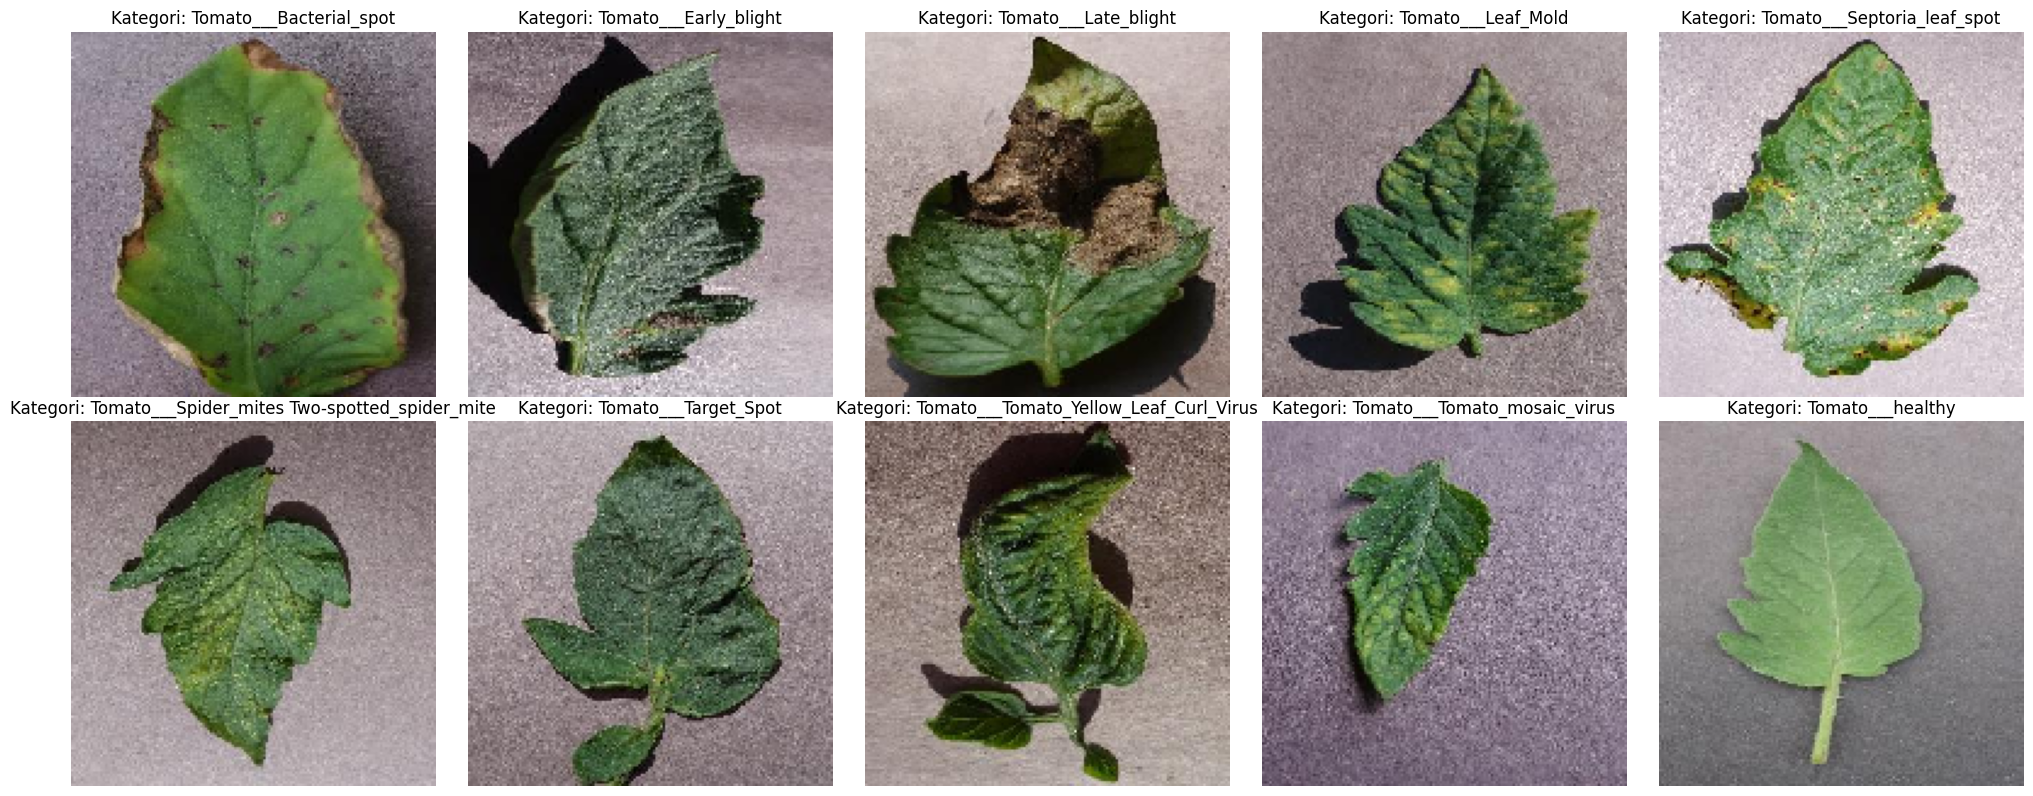

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Örnek değerler (sizin ortamınıza göre ayarlayın)

img_width, img_height = 150, 150  # Görüntü boyutları (sizin ayarlarınıza göre)

# Kategorileri ve dizinleri al
class_names = list(train_generator.class_indices.keys())

# 2 satır ve 5 sütunlu bir figür oluştur
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_data_dir, class_name)
    img_file = os.listdir(class_dir)[0]  # Her kategoriden sadece bir örnek seçiliyor
    img_path = os.path.join(class_dir, img_file)

    # Görüntüyü yükle ve görselleştir
    img = image.load_img(img_path, target_size=(img_width, img_height))

    # Satır ve sütun indekslerini hesapla
    row, col = divmod(i, 5)

    axes[row, col].imshow(img)
    axes[row, col].set_title(f'Kategori: {class_name}')
    axes[row, col].axis('off')  # Eksenleri kapat

# Aralarındaki boşlukları ayarla
plt.tight_layout()
plt.show()


In [ ]:
# DenseNet201 Modeli

base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Yeni modeli oluşturma
model = tf.keras.models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator, use_multiprocessing=True, workers = 64)

Epoch 1/10


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


574/574 [==============================] - 1454s 2s/step - loss: 0.4561 - accuracy: 0.8584 - val_loss: 2.4107 - val_accuracy: 0.6447
Epoch 2/10
574/574 [==============================] - 154s 259ms/step - loss: 0.2259 - accuracy: 0.9313 - val_loss: 0.4416 - val_accuracy: 0.8719
Epoch 3/10
574/574 [==============================] - 153s 258ms/step - loss: 0.1781 - accuracy: 0.9447 - val_loss: 0.6862 - val_accuracy: 0.8063
Epoch 4/10
574/574 [==============================] - 156s 263ms/step - loss: 0.1503 - accuracy: 0.9537 - val_loss: 2.5302 - val_accuracy: 0.7433
Epoch 5/10
574/574 [==============================] - 156s 262ms/step - loss: 0.1270 - accuracy: 0.9617 - val_loss: 0.2743 - val_accuracy: 0.9273
Epoch 6/10
574/574 [==============================] - 155s 261ms/step - loss: 0.1181 - accuracy: 0.9628 - val_loss: 1.9834 - val_accuracy: 0.6817
Epoch 7/10
574/574 [==============================] - 155s 261ms/step - loss: 0.1085 - accuracy: 0.9666 - val_loss: 0.7151 - val_accuracy

In [ ]:
model.save('drive/MyDrive/TomatoDisease/densenet_201.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
tf.keras.saving.load_model('drive/MyDrive/TomatoDisease/densenet_201.h5', custom_objects=None, compile=True, safe_mode=True)

In [ ]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)

test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps_per_epoch)
print(f'Test Doğruluğu: {test_accuracy * 100:.2f}%')

144/144 [==============================] - 15s 106ms/step - loss: 0.0698 - accuracy: 0.9800
Test Doğruluğu: 98.00%


In [ ]:
predIdx=model.predict(test_generator)
pred=np.argmax(predIdx,axis=1)

144/144 [==============================] - 18s 106ms/step


In [ ]:
print(classification_report(test_generator.classes,pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       425
           1       0.98      0.94      0.96       480
           2       0.95      0.98      0.96       463
           3       0.99      0.99      0.99       470
           4       0.99      0.97      0.98       436
           5       0.95      1.00      0.97       445
           6       0.97      0.95      0.96       457
           7       0.99      1.00      0.99       490
           8       1.00      1.00      1.00       458
           9       0.99      1.00      0.99       481

    accuracy                           0.98      4605
   macro avg       0.98      0.98      0.98      4605
weighted avg       0.98      0.98      0.98      4605



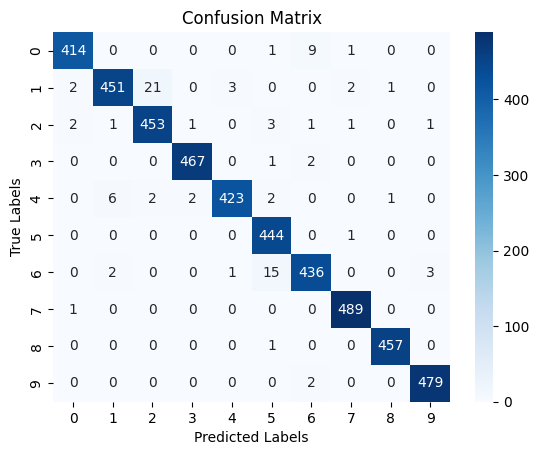

In [ ]:
import seaborn as sns
cm = confusion_matrix(test_generator.classes, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

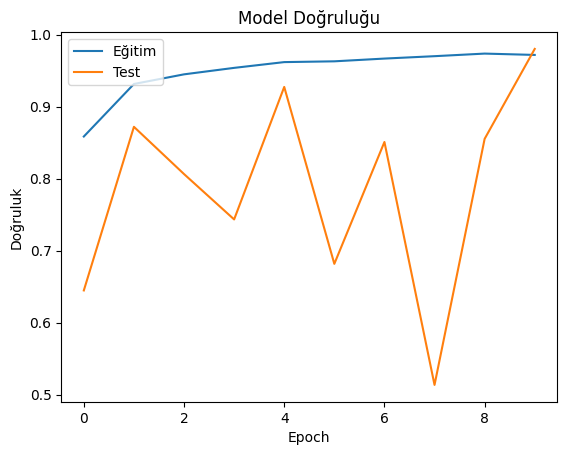

In [ ]:
# Doğruluk oranını çizme
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend(['Eğitim', 'Test'], loc='upper left')
plt.show()

In [ ]:
from keras.models import load_model


densenet=load_model('/content/drive/MyDrive/TomatoDisease/densenet_201.h5')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d (  (None, 1920)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               983552    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 19310666 (73.66 MB)
Trainable params: 19081610 (72.79 MB)
Non-trainable params: 229056 (894.75 KB)
_________